<a href="https://colab.research.google.com/github/lbnartey1/Student-score-prediction/blob/main/StudentsScorePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Importing Libraries and Dependencies.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# 2. Loading Dataset.

In [16]:
data = pd.read_csv('/content/drive/MyDrive/Elevvo Internship./Task 1 - Student score prediction - Complete/StudentPerformanceFactors.csv')
data.head(10)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
5,19,88,Medium,Medium,Yes,8,89,Medium,Yes,3,Medium,Medium,Public,Positive,3,No,Postgraduate,Near,Male,71
6,29,84,Medium,Low,Yes,7,68,Low,Yes,1,Low,Medium,Private,Neutral,2,No,High School,Moderate,Male,67
7,25,78,Low,High,Yes,6,50,Medium,Yes,1,High,High,Public,Negative,2,No,High School,Far,Male,66
8,17,94,Medium,High,No,6,80,High,Yes,0,Medium,Low,Private,Neutral,1,No,College,Near,Male,69
9,23,98,Medium,Medium,Yes,8,71,Medium,Yes,0,High,High,Public,Positive,5,No,High School,Moderate,Male,72


## 2.1 Data Wrangling.

In [17]:
data.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

<Axes: >

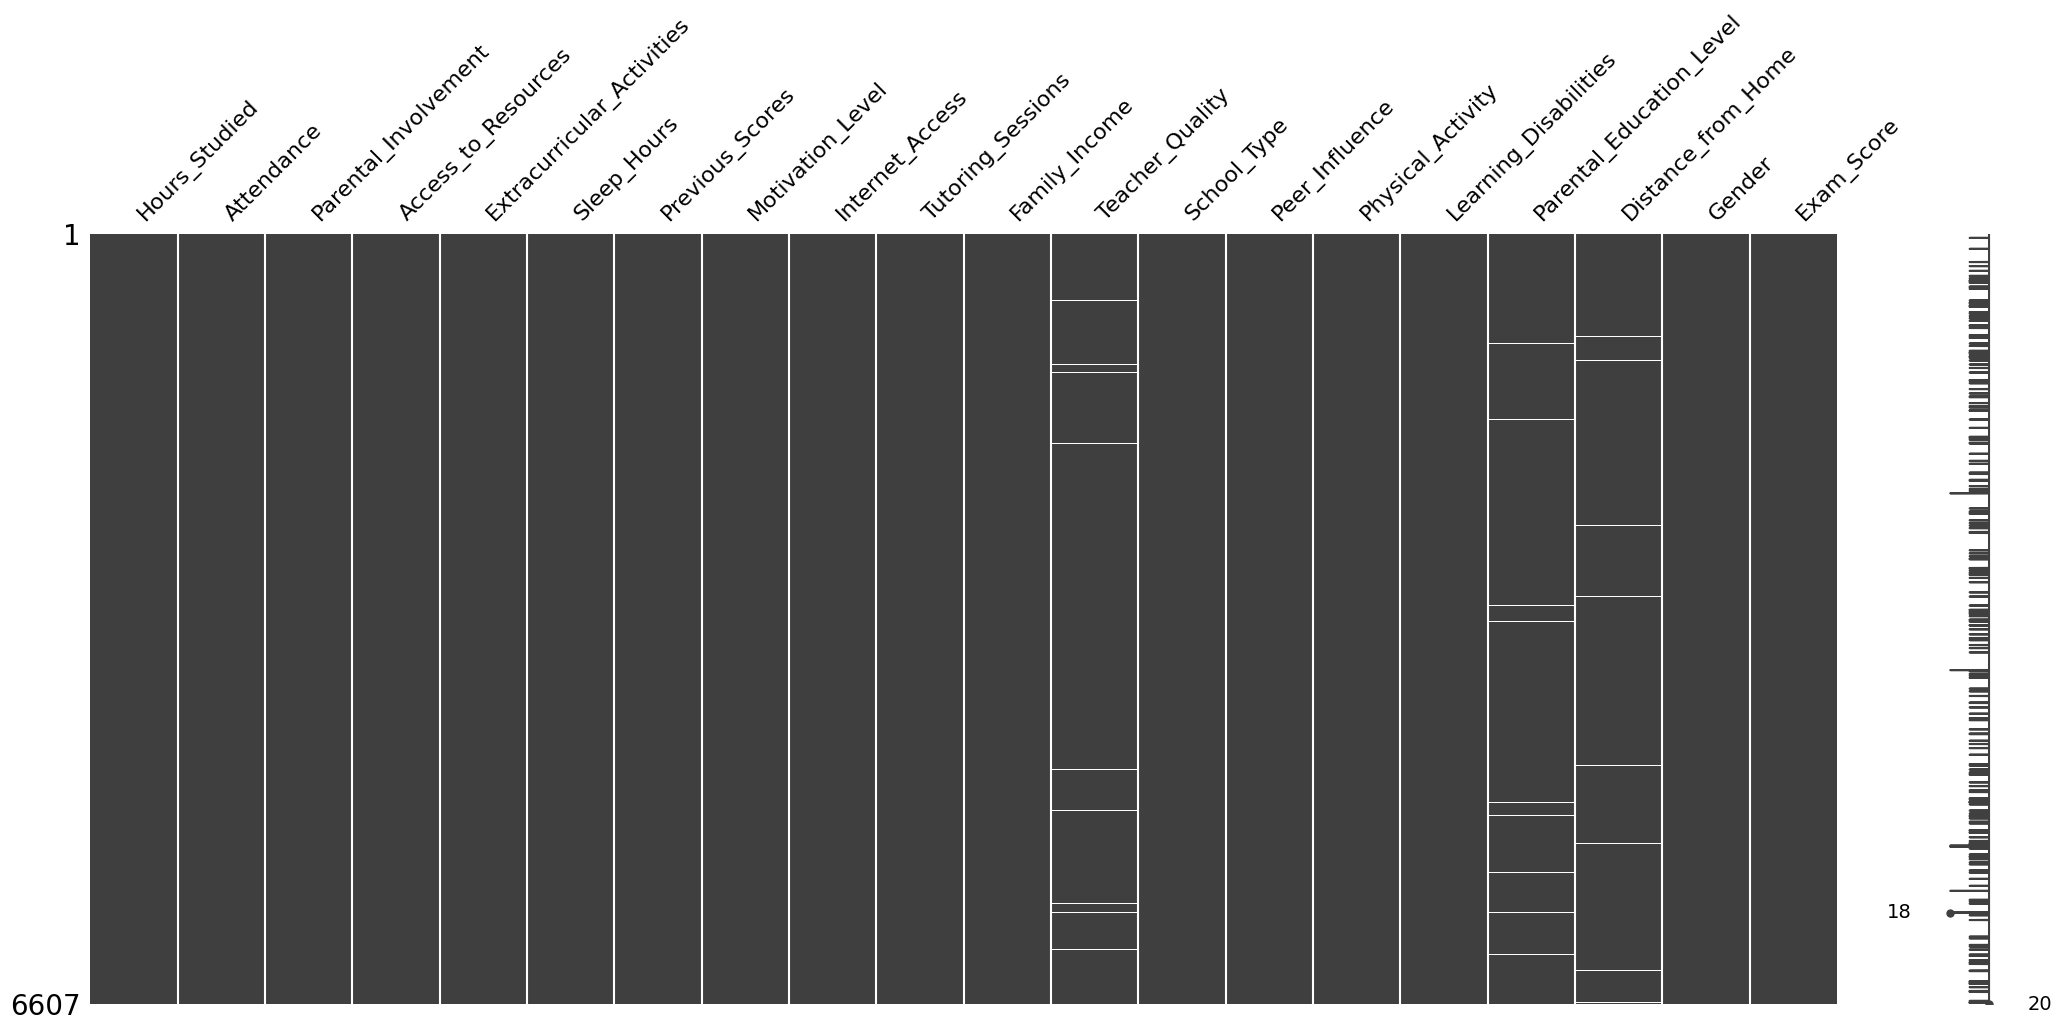

In [19]:
msn.matrix(data) #Checking for empty cells

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


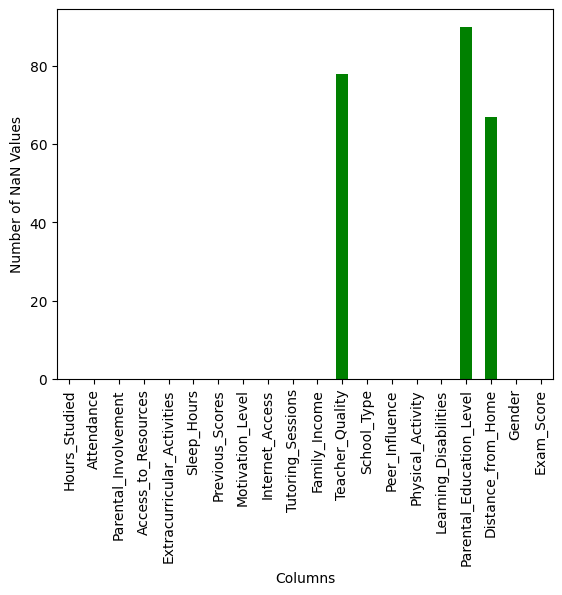

In [20]:
nan_counts = data.isnull().sum()
print(nan_counts)

nan_counts.plot(kind='bar',color='green',)  #plot values of Nan as green columns.
plt.xlabel('Columns')
plt.ylabel('Number of NaN Values')
plt.show()

## 2.2. Data Cleaning.

In [21]:
cleaned_data = data.dropna()
cleaned_data

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


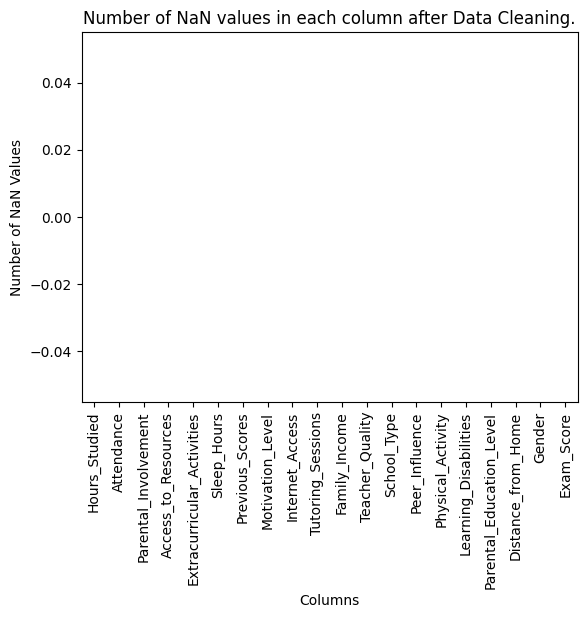

In [22]:
second_nan_count = cleaned_data.isnull().sum()
second_nan_count.plot(kind = 'bar', color = 'green')
plt.title('Number of NaN values in each column after Data Cleaning.')
plt.xlabel('Columns')
plt.ylabel('Number of NaN Values')
plt.show()

# 3. Data Visualization.

In [23]:
columns = cleaned_data.columns
columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

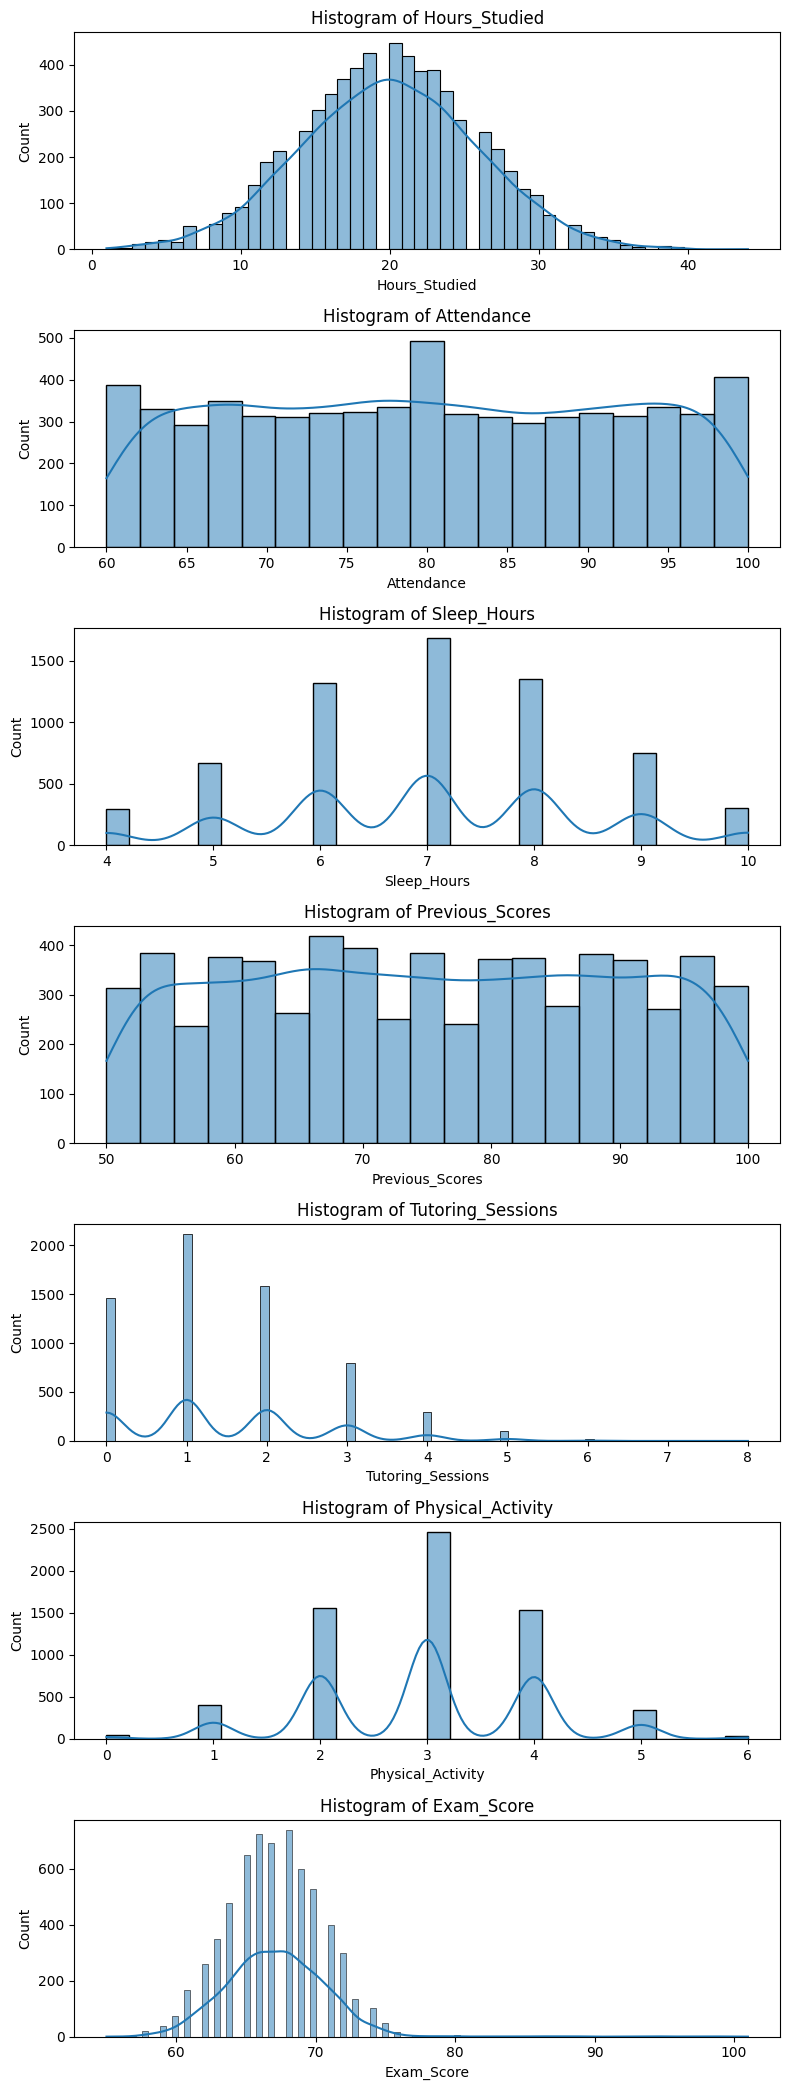

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

parameters = [
    'Hours_Studied', 'Attendance', 'Parental_Involvement',
    'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
    'Previous_Scores', 'Motivation_Level', 'Internet_Access',
    'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
    'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
    'Parental_Education_Level', 'Distance_from_Home', 'Gender',
    'Exam_Score'
]

numeric_data = cleaned_data[parameters].select_dtypes(include=['int64', 'float64'])

num_features = len(numeric_data.columns)

fig, axes = plt.subplots(num_features, 1, figsize=(8, 3 * num_features))

for i, feature in enumerate(numeric_data.columns):
    sns.histplot(numeric_data[feature], kde=True, ax=axes[i])
    axes[i].set_title(f'Histogram of {feature}')

plt.tight_layout()
plt.show()


In [25]:
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6378 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6378 non-null   int64 
 1   Attendance                  6378 non-null   int64 
 2   Parental_Involvement        6378 non-null   object
 3   Access_to_Resources         6378 non-null   object
 4   Extracurricular_Activities  6378 non-null   object
 5   Sleep_Hours                 6378 non-null   int64 
 6   Previous_Scores             6378 non-null   int64 
 7   Motivation_Level            6378 non-null   object
 8   Internet_Access             6378 non-null   object
 9   Tutoring_Sessions           6378 non-null   int64 
 10  Family_Income               6378 non-null   object
 11  Teacher_Quality             6378 non-null   object
 12  School_Type                 6378 non-null   object
 13  Peer_Influence              6378 non-null   object
 1

In [26]:
categorical_cols = [col for col in cleaned_data.columns if cleaned_data[col].dtype == 'object']
for col in categorical_cols:
    print(f"Column {col}: {cleaned_data[col].unique()}")

Column Parental_Involvement: ['Low' 'Medium' 'High']
Column Access_to_Resources: ['High' 'Medium' 'Low']
Column Extracurricular_Activities: ['No' 'Yes']
Column Motivation_Level: ['Low' 'Medium' 'High']
Column Internet_Access: ['Yes' 'No']
Column Family_Income: ['Low' 'Medium' 'High']
Column Teacher_Quality: ['Medium' 'High' 'Low']
Column School_Type: ['Public' 'Private']
Column Peer_Influence: ['Positive' 'Negative' 'Neutral']
Column Learning_Disabilities: ['No' 'Yes']
Column Parental_Education_Level: ['High School' 'College' 'Postgraduate']
Column Distance_from_Home: ['Near' 'Moderate' 'Far']
Column Gender: ['Male' 'Female']


In [27]:
encoded_data = cleaned_data.copy()

In [28]:
ordinal_mappings = {
    'Parental_Involvement': {'Low':0, 'Medium':1, 'High':2},
    'Access_to_Resources': {'Low':0, 'Medium':1, 'High':2},
    'Motivation_Level': {'Low':0, 'Medium':1, 'High':2},
    'Family_Income': {'Low':0, 'Medium':1, 'High':2},
    'Teacher_Quality': {'Low':0, 'Medium':1, 'High':2},
    'Parental_Education_Level': {'High School':0, 'College':1, 'Postgraduate':2},
    'Distance_from_Home': {'Near':0, 'Moderate':1, 'Far':2},
    'Peer_Influence': {'Negative':0, 'Neutral':1, 'Positive':2}
}

for col, mapping in ordinal_mappings.items():
    encoded_data[col] = encoded_data[col].map(mapping)

In [29]:
binary_cols = [
    'Extracurricular_Activities',
    'Internet_Access',
    'Learning_Disabilities',
    'School_Type',
    'Gender'
]

encoded_data = pd.get_dummies(encoded_data,
                              columns=binary_cols,
                              drop_first=True)

In [30]:
encoded_data

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,Peer_Influence,Physical_Activity,Parental_Education_Level,Distance_from_Home,Exam_Score,Extracurricular_Activities_Yes,Internet_Access_Yes,Learning_Disabilities_Yes,School_Type_Public,Gender_Male
0,23,84,0,2,7,73,0,0,0,1,2,3,0,0,67,False,True,False,True,True
1,19,64,0,1,8,59,0,2,1,1,0,4,1,1,61,False,True,False,True,False
2,24,98,1,1,7,91,1,2,1,1,1,4,2,0,74,True,True,False,True,True
3,29,89,0,1,8,98,1,1,1,1,0,4,0,1,71,True,True,False,True,True
4,19,92,1,1,6,65,1,3,1,2,1,4,1,0,70,True,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,2,1,7,76,1,1,2,1,2,2,0,0,68,False,True,False,True,False
6603,23,76,2,1,8,81,1,3,0,2,2,2,0,0,69,False,True,False,True,False
6604,20,90,1,0,6,65,0,3,0,1,0,2,2,0,68,True,True,False,True,False
6605,10,86,2,2,6,91,2,2,0,1,2,3,0,2,68,True,True,False,False,False


In [31]:
encoded_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6378 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Hours_Studied                   6378 non-null   int64
 1   Attendance                      6378 non-null   int64
 2   Parental_Involvement            6378 non-null   int64
 3   Access_to_Resources             6378 non-null   int64
 4   Sleep_Hours                     6378 non-null   int64
 5   Previous_Scores                 6378 non-null   int64
 6   Motivation_Level                6378 non-null   int64
 7   Tutoring_Sessions               6378 non-null   int64
 8   Family_Income                   6378 non-null   int64
 9   Teacher_Quality                 6378 non-null   int64
 10  Peer_Influence                  6378 non-null   int64
 11  Physical_Activity               6378 non-null   int64
 12  Parental_Education_Level        6378 non-null   int64
 13  Distance

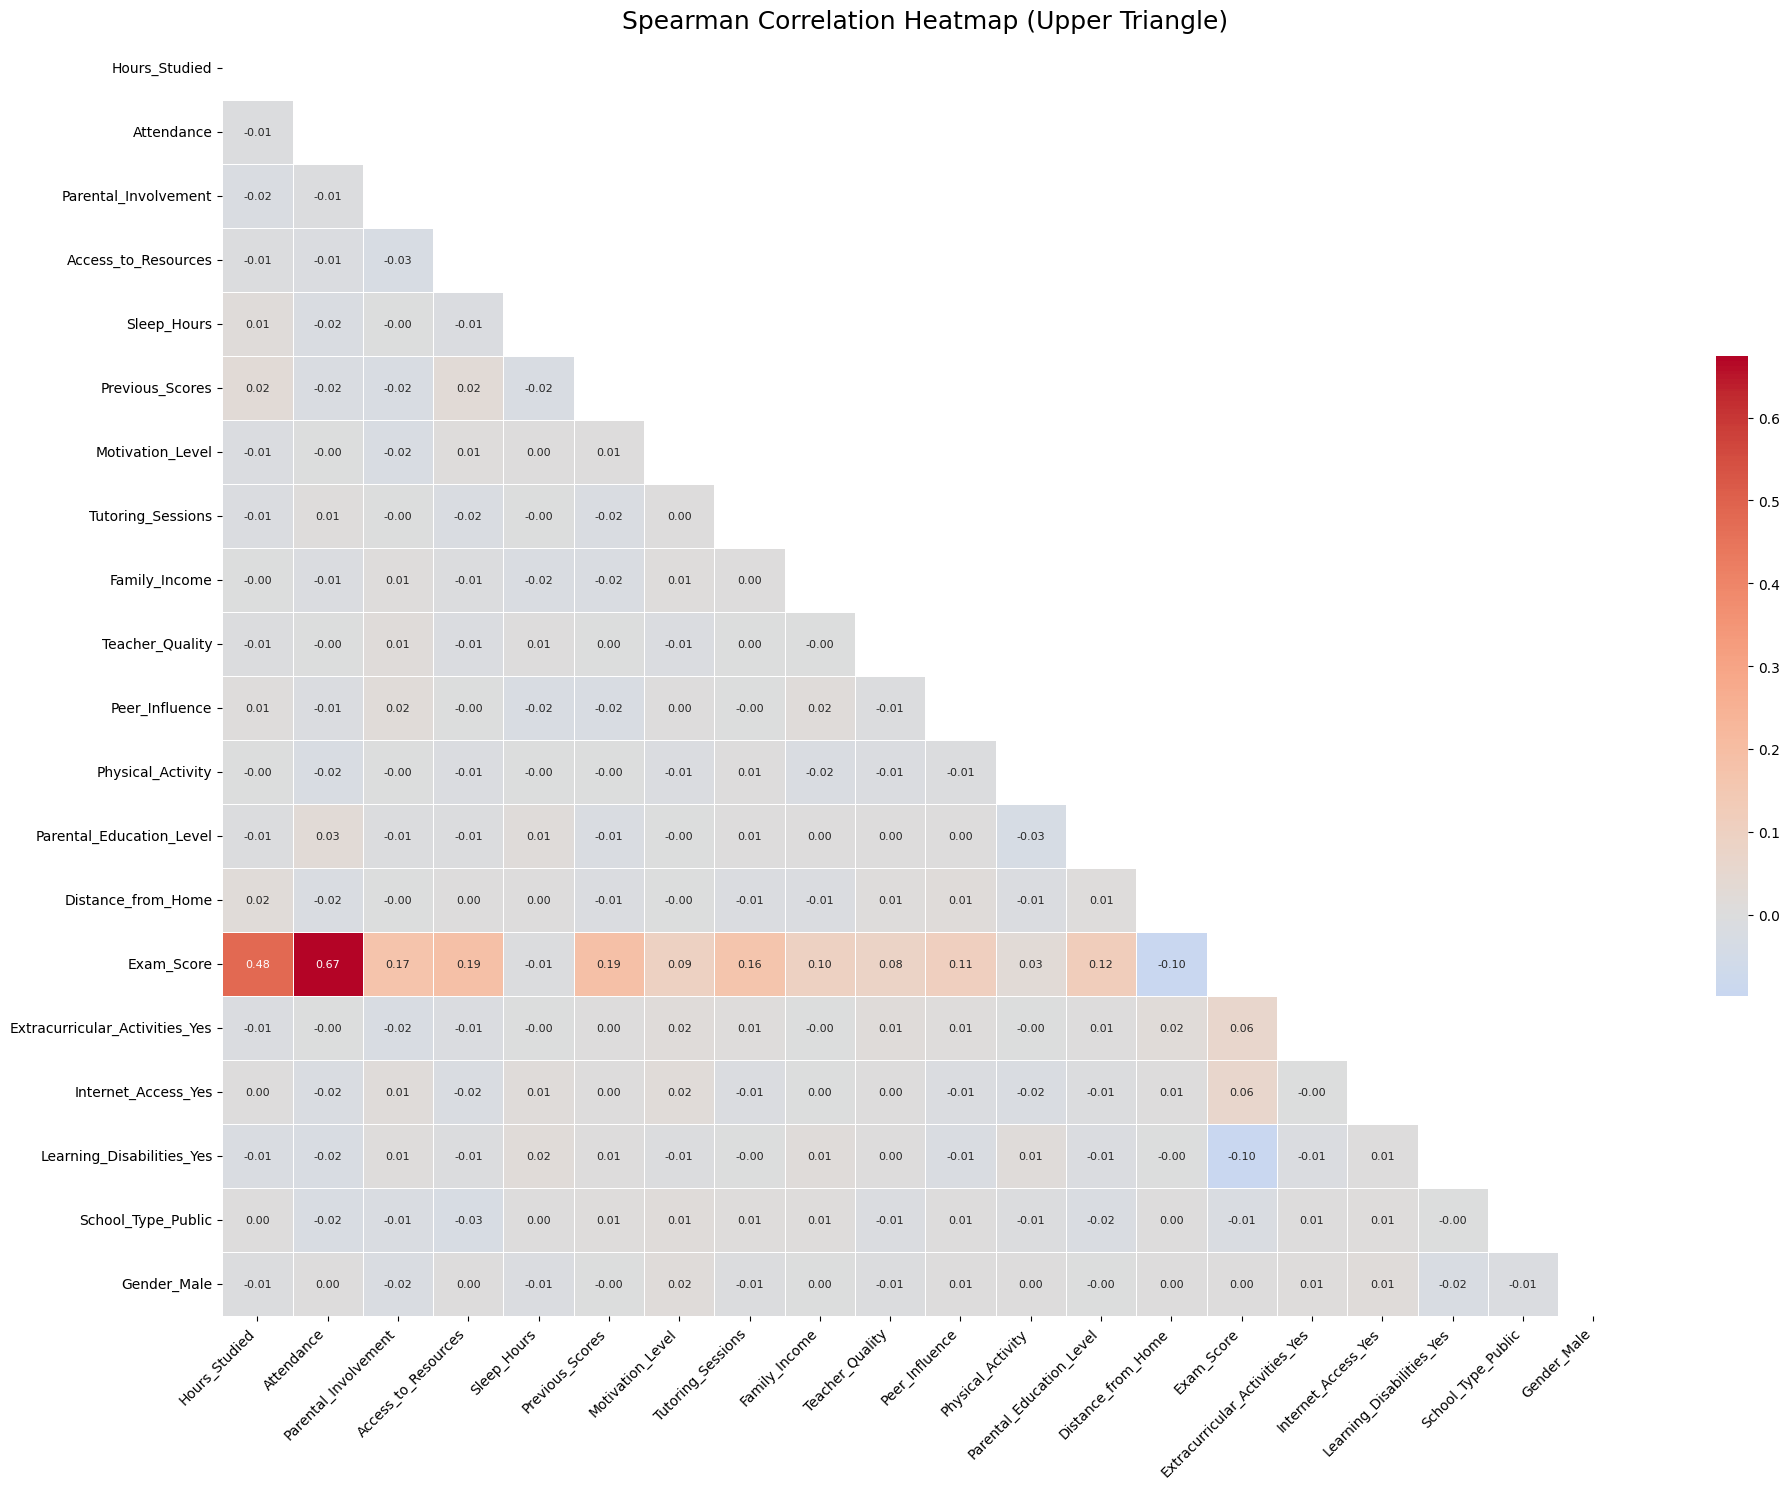

In [32]:
# Compute Spearman correlation
c_m = encoded_data.corr(method='spearman')

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(c_m, dtype=bool))

# Set up the matplotlib figure
plt.figure(figsize=(20, 15))

# Draw the heatmap
sns.heatmap(
    c_m,
    mask=mask,             # hide upper triangle
    annot=True,            # show correlation values
    fmt=".2f",             # 2 decimal places
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},  # smaller color bar
    annot_kws={"size":8}       # smaller annotation font
)

plt.title("Spearman Correlation Heatmap (Upper Triangle)", fontsize=18)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 4. Data Separation into Features and Targets.

In [33]:
X = encoded_data.drop(['Exam_Score',
                       'Teacher_Quality',
                       'Physical_Activity'
                       ], axis = 1)
y = encoded_data.Exam_Score

# 5. Data Scaling.

In [34]:
scaler = StandardScaler()

# Fitting the scaler on the training data and transforming both training and testing data
X_scaled = scaler.fit_transform(X)

X_scaled

array([[ 0.50507871,  0.34452035, -1.56187552, ..., -0.34203471,
         0.6621407 ,  0.85404486],
       [-0.16325988, -1.38710878, -1.56187552, ..., -0.34203471,
         0.6621407 , -1.17089868],
       [ 0.67216335,  1.55666073, -0.12295568, ..., -0.34203471,
         0.6621407 ,  0.85404486],
       ...,
       [ 0.00382477,  0.86400908, -0.12295568, ..., -0.34203471,
         0.6621407 , -1.17089868],
       [-1.66702171,  0.51768326,  1.31596417, ..., -0.34203471,
        -1.51025302, -1.17089868],
       [-0.83159847, -1.12736441, -0.12295568, ..., -0.34203471,
         0.6621407 ,  0.85404486]])

# 6. Model Training - Linear Regression

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (5102, 17)
X_test shape: (1276, 17)


In [36]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully.")

Linear Regression Model Trained Successfully.


# 7. Model Evaluation and Visualization.

In [37]:
y_pred = model.predict(X_test)

print("Test set score: {:.2f}".format(model.score(X_test, y_test)))

Test set score: 0.73


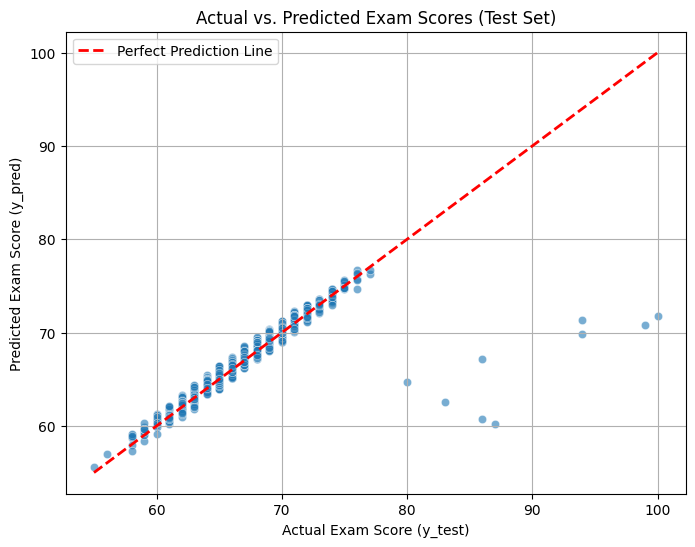

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)

# Add a diagonal line for perfect predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2, label='Perfect Prediction Line')

plt.title('Actual vs. Predicted Exam Scores (Test Set)')
plt.xlabel('Actual Exam Score (y_test)')
plt.ylabel('Predicted Exam Score (y_pred)')
plt.grid(True)
plt.legend()
plt.show()

In [39]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Squared Error: 4.24
R-squared: 0.73


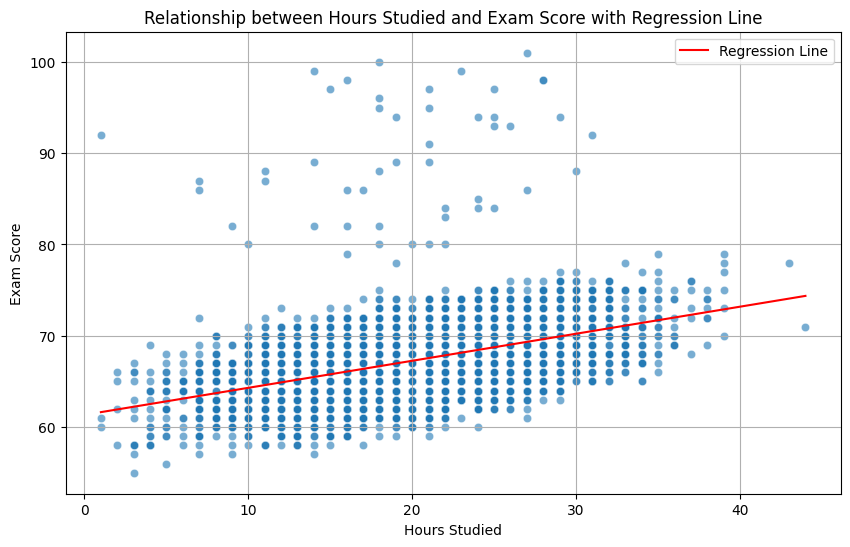

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd # Import pandas if not already imported

plt.figure(figsize=(10, 6))
sns.scatterplot(x=cleaned_data['Hours_Studied'], y=cleaned_data['Exam_Score'], alpha=0.6)

# Plot the regression line
# Create a range of Hours_Studied values for prediction
x_range = np.linspace(cleaned_data['Hours_Studied'].min(), cleaned_data['Hours_Studied'].max(), 100).reshape(-1, 1)

# Create a base DataFrame with mean values of all features in X (used during scaler fit)
x_base_values = X.mean().to_frame().T # X is the DataFrame before scaling

# Create a DataFrame for plotting where 'Hours_Studied' varies and other features are constant (at their mean)
x_plot_df = pd.DataFrame(np.repeat(x_base_values.values, len(x_range), axis=0), columns=X.columns)

# Replace the 'Hours_Studied' column with the varying x_range values
x_plot_df['Hours_Studied'] = x_range

# Scale this new DataFrame using the same scaler fitted on X
x_range_scaled = scaler.transform(x_plot_df)

# Predict Exam_Score for these scaled values
y_range_pred = model.predict(x_range_scaled)

sns.lineplot(x=x_range.flatten(), y=y_range_pred, color='red', label='Regression Line')

plt.title('Relationship between Hours Studied and Exam Score with Regression Line')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.grid(True)
plt.legend()
plt.show()

# Bonus

Try polynomial regression and compare performance.

Try experimenting with different feature combinations.
1. Adding all features and adding features to boost performance of model.

Polynomial Regression is a form of regression analysis in which the relationship between the independent variable \(X\) and the dependent variable \(Y\) is modeled as an \(n\)-th degree polynomial. It allows us to model non-linear relationships and can capture more complex patterns in the data compared to simple linear regression.

### Import necessary libraries.
We'll need `PolynomialFeatures` from `sklearn.preprocessing` to transform our features into polynomial terms.

In [41]:
from sklearn.preprocessing import PolynomialFeatures

### Create Polynomial Features.
We will transform our `Hours_Studied` feature (`X_scaled`) into polynomial features. Let's start with a degree of 2 to see a quadratic relationship.

In [42]:
poly_features = PolynomialFeatures(degree=2)
X_poly = poly_features.fit_transform(X_scaled)

print("Original X_scaled shape:", X_scaled.shape)
print("Polynomial features X_poly shape:", X_poly.shape)


Original X_scaled shape: (6378, 17)
Polynomial features X_poly shape: (6378, 171)


### Split the data into training and testing sets.
We need to split our newly created polynomial features (`X_poly`) and the target variable (`y`) into training and testing sets.

In [43]:
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, y, test_size=0.2, random_state=42)

print("X_train_poly shape:", X_train_poly.shape)
print("X_test_poly shape:", X_test_poly.shape)

X_train_poly shape: (5102, 171)
X_test_poly shape: (1276, 171)


### Train the Polynomial Regression Model.
Now, we'll train a `LinearRegression` model on these polynomial features. While the relationship is polynomial, the model itself is still linear in the transformed features.

In [44]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train_poly)

print("Polynomial Regression Model Trained Successfully.")

Polynomial Regression Model Trained Successfully.


### Evaluate the Polynomial Regression Model.
We'll make predictions on the test set and evaluate the model's performance using R-squared and Mean Squared Error (MSE).

In [45]:
y_pred_poly = poly_model.predict(X_test_poly)

mse_poly = mean_squared_error(y_test_poly, y_pred_poly)
r2_poly = r2_score(y_test_poly, y_pred_poly)

print(f"Polynomial Regression Mean Squared Error: {mse_poly:.2f}")
print(f"Polynomial Regression R-squared: {r2_poly:.2f}")

print("\n--- Comparison with Simple Linear Regression ---")
print(f"Simple Linear Regression Mean Squared Error: {mse:.2f}")
print(f"Simple Linear Regression R-squared: {r2:.2f}")

Polynomial Regression Mean Squared Error: 4.45
Polynomial Regression R-squared: 0.71

--- Comparison with Simple Linear Regression ---
Simple Linear Regression Mean Squared Error: 4.24
Simple Linear Regression R-squared: 0.73


### Visualize the Polynomial Regression Model.
Let's visualize the polynomial regression line alongside the scatter plot of `Hours_Studied` and `Exam_Score`.

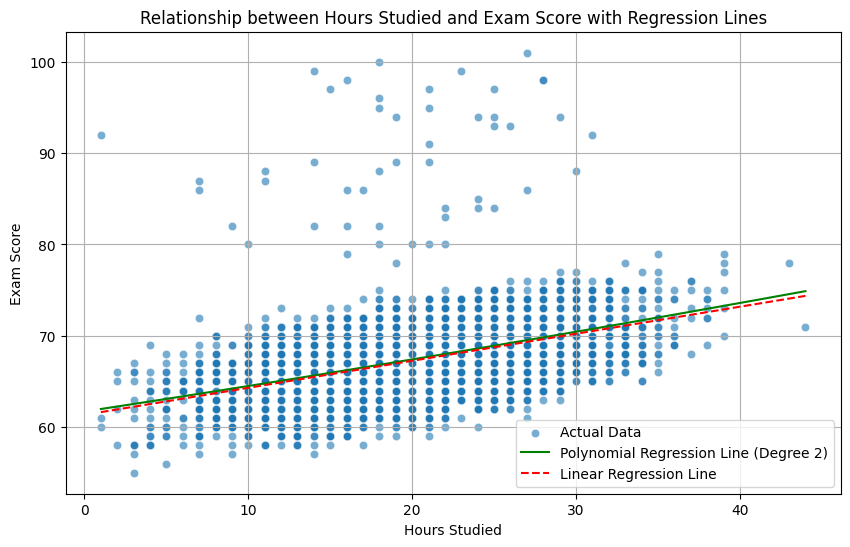

In [46]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=cleaned_data['Hours_Studied'], y=cleaned_data['Exam_Score'], alpha=0.6, label='Actual Data')

# Create a range of Hours_Studied values for prediction
x_range_orig = np.linspace(cleaned_data['Hours_Studied'].min(), cleaned_data['Hours_Studied'].max(), 100).reshape(-1, 1)

# Create a base DataFrame with mean values of all features in X (used during scaler fit)
x_base_values_for_poly = X.mean().to_frame().T # X is the DataFrame before scaling

# Create a DataFrame for plotting where 'Hours_Studied' varies and other features are constant (at their mean)
x_plot_df_poly = pd.DataFrame(np.repeat(x_base_values_for_poly.values, len(x_range_orig), axis=0), columns=X.columns)

# Replace the 'Hours_Studied' column with the varying x_range_orig values
x_plot_df_poly['Hours_Studied'] = x_range_orig

# Scale this new DataFrame using the same scaler fitted on X
x_range_scaled_for_poly = scaler.transform(x_plot_df_poly)

# Transform to polynomial features
x_range_poly = poly_features.transform(x_range_scaled_for_poly)

# Predict Exam_Score for these polynomial values
y_range_pred_poly = poly_model.predict(x_range_poly)

sns.lineplot(x=x_range_orig.flatten(), y=y_range_pred_poly, color='green', label='Polynomial Regression Line (Degree 2)')
sns.lineplot(x=x_range.flatten(), y=y_range_pred, color='red', linestyle='--', label='Linear Regression Line')

plt.title('Relationship between Hours Studied and Exam Score with Regression Lines')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.grid(True)
plt.legend()
plt.show()